# Product Strength Prediction

## Background and Aim

Cured product flexural strength is an important quality measure, but curing, sample preparation, and technician availability delay direct measurement. This project uses anonymised quality-control, manufacturing, and maintenance data from Concrete Canvas Ltd. to predict flexural strength and identify the factors associated with its variation, supporting both earlier estimation and future process improvement.

Linear and non-linear regression models are compared using cross-validation. SHAP values and linear model coefficients provide complementary explanations of the predictions and fitted relationships.

The dataset and feature names have been anonymised, and commercially sensitive details have been removed. Source material and proprietary data-integration and feature-engineering procedures are therefore not included.

The public repository also excludes the private development Git history to prevent sensitive information being exposed through intermediate versions.

## Contents

- [Background and Aim](#background-and-aim)
- [Data Preparation](#data-preparation)
- [Modelling Approach](#modelling-approach)
- [Models](#models)
  - [Model 1: Linear Regression](#model-1-linear-regression)
  - [Model 2: Lasso Regression](#model-2-lasso-regression)
  - [Model 3: Ridge Regression](#model-3-ridge-regression)
  - [Model 4: Linear Regression with Standardisation](#model-4-linear-regression-with-standardisation)
  - [Model 5: Lasso Regression with Standardisation](#model-5-lasso-regression-with-standardisation)
  - [Model 6: Ridge Regression with Standardisation](#model-6-ridge-regression-with-standardisation)
  - [Model 7: Decision Tree Regression](#model-7-decision-tree-regression)
  - [Model 8: Random Forest Regression](#model-8-random-forest-regression)
  - [Model 9: Stochastic Gradient Boosting Regression](#model-9-stochastic-gradient-boosting-regression)
  - [Model 10: Neural Network Regression MLP](#model-10-neural-network-regression-mlp)
- [Model Comparison](#model-comparison)
- [SHAP Analysis](#shap-analysis-model-8-random-forest)
- [Coefficient Analysis](#coefficient-analysis-model-5-lasso)
- [Conclusions and Limitations](#conclusions-and-limitations)

## Data Preparation

### Data Integration

Quality-control, manufacturing, and maintenance records were combined into a single modelling dataset. Each of these sources record observations at different frequencies; quality-control measurements occur approximately once per production day. `pandas.merge_asof` was used to associate each quality-control record with the relevant manufacturing and maintenance records.

### Feature Engineering

Features were engineered to describe product characteristics together with the manufacturing and maintenance context associated with each strength measurement.

### Imports and Setup

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

import shap


def show(item, label="Unlabelled object"):
    """Print an object with a descriptive label."""
    print(f"\n>> {label}")
    print(item)


plt.close()

### Loading the Data

In [2]:
data = pd.read_pickle("../data/combined_modelling_data.pkl")

print("Features and target loaded:")
for col in data.columns:
    print(f"- {col}")

Features and target loaded:
- qc_sample_location
- setting_rate
- material_dimension
- sample_mass
- stitching_measurement
- sample_dimension
- formulation_property
- relative_position_on_day
- relative_batch_weight
- production_line_property
- relative_time_since_maintenance
- storage_property
- variant
- formulation_component_1
- formulation_component_2
- flexural_strength_index


### Feature Encoding

Sample location is encoded as a binary feature. The selected predictors describe the product and its production context.

In [3]:
data["qc_sample_location_enc"] = data["qc_sample_location"].map({"A": 0, "B": 1})

feature_list = [
    "qc_sample_location_enc",
    "setting_rate",
    "material_dimension",
    "sample_mass",
    "stitching_measurement",
    "sample_dimension",
    "formulation_property",
    "relative_position_on_day",
    "relative_batch_weight",
    "production_line_property",
    "relative_time_since_maintenance",
    "storage_property",
]

### Analysis Population

The analysis focuses on one product variant and a fixed combination of formulation components to compare samples under similar production conditions.

In [4]:
condition = (
    (data["variant"] == "variant_b")
    & (data["formulation_component_1"] == "component_1_type_a")
    & (data["formulation_component_2"] == "component_2_type_a")
)

### Predictors and Target

The selected features form the predictor matrix `X`; `flexural_strength_index` is the target `y`. To protect commercially sensitive absolute strength values, the target is expressed as a relative index, with 100 representing the mean observed flexural strength in the modelling dataset. The transformation preserves the ordering and relative ratios of the original target values.

In [5]:
X = data.loc[condition, feature_list].reset_index(drop=True)
y = data.loc[condition, "flexural_strength_index"].reset_index(drop=True)

### Data Inspection

The modelling data were checked for structure, data types, and summary statistics. Detailed inspection outputs are omitted to protect commercially sensitive information.

### Handling Missing Values

Missing values in `storage_property` are handled by median imputation within each modelling pipeline. During cross-validation, medians are learned only from the training fold and applied to the validation fold.

## Modelling Approach

Hyperparameters were assessed using a shared shuffled 5-fold cross-validation (CV) partition, while the chosen models were evaluated using a shared shuffled 10-fold partition. Both splitters use seed 27, providing reproducible and consistent fold assignments across models.

Performance is summarised using mean R² and mean fold RMSE, with standard deviations showing variation across folds. RMSE is reported in strength-index points. Higher R² and lower RMSE indicate better predictive performance. Every model uses a pipeline with median imputation followed by standard scaling where required. During cross-validation, preprocessing is fitted only on each training fold and then applied to its validation fold.

Reusable functions are used to collect model results, evaluate regularisation strengths, and plot tuning performance.

In [6]:
models_df = pd.DataFrame()

# Shared 5-fold partition for consistent hyperparameter tuning across models.
tuning_cv = KFold(n_splits=5, shuffle=True, random_state=27)


def add_model_to_df(model_label, standardisation, cv_rsq_array, cv_nmse_array):
    """Add cross-validation results for a model to the results DataFrame."""
    global models_df
    cv_rsq_mean = np.mean(cv_rsq_array)
    cv_rsq_std = np.std(cv_rsq_array)
    cv_rmse_mean = np.mean(np.sqrt(-cv_nmse_array))
    cv_rmse_std = np.std(np.sqrt(-cv_nmse_array))
    model_dict = {
        "Standardisation": standardisation,
        "cv_R2 mean": cv_rsq_mean,
        "cv_R2 std": cv_rsq_std,
        "cv_RMSE mean": cv_rmse_mean,
        "cv_RMSE std": cv_rmse_std,
    }
    models_df = pd.concat([models_df, pd.DataFrame(model_dict, index=[model_label])])


def evaluate_chosen_model(model_label, standardisation, model):
    """Evaluate a chosen model using 10-fold cross-validation."""

    kf = KFold(n_splits=10, shuffle=True, random_state=27)

    cv_rsq = cross_val_score(model, X, y, cv=kf)
    cv_nmse = cross_val_score(model, X, y, cv=kf, scoring="neg_mean_squared_error")

    add_model_to_df(model_label, standardisation, cv_rsq, cv_nmse)

    display(models_df.iloc[[-1]].round(3))


def evaluate_alpha_values(model_class, scaler, alphas, X, y):
    """Evaluate cross-validated R² and RMSE across a range of alpha values.
    Applicable where the model has only one hyperparameter: alpha."""

    kf = tuning_cv

    rsq_mean = []
    rsq_std = []
    rmse_mean = []
    rmse_std = []

    for alpha in alphas:
        scaler_step = "passthrough" if scaler is None else scaler()

        pipeline = Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", scaler_step),
                ("model", model_class(alpha=alpha)),
            ]
        )

        cv_rsq = cross_val_score(pipeline, X, y, cv=kf)
        cv_nmse = cross_val_score(pipeline, X, y, cv=kf, scoring="neg_mean_squared_error")
        cv_rmse = np.sqrt(-cv_nmse)

        rsq_mean.append(np.mean(cv_rsq))
        rsq_std.append(np.std(cv_rsq))
        rmse_mean.append(np.mean(cv_rmse))
        rmse_std.append(np.std(cv_rmse))

    return rsq_mean, rsq_std, rmse_mean, rmse_std


def plot_alpha_results(alphas, means, stds, metric, model_name):
    """Plot cross-validated performance across a range of alpha values.
    Applicable where the model has only one hyperparameter: alpha."""

    plt.close()

    fig, ax = plt.subplots(figsize=(6, 4))

    error_bars = ax.errorbar(np.arange(1, len(alphas) + 1), means, yerr=stds, fmt="o")
    for bar_collection in error_bars.lines[2]:
        bar_collection.set_alpha(0.4)

    if metric == "R-squared":
        ax.axhline(0, color="k", lw=0.8)

    ax.set_xticks(np.arange(1, len(alphas) + 1))
    ax.set_xticklabels(
        [
            np.format_float_scientific(alpha, trim="-") if alpha < 0.001 else str(alpha)
            for alpha in alphas
        ]
    )
    metric_label = "R²" if metric == "R-squared" else metric
    ax.set_xlabel("Alpha")
    ax.set_ylabel(f"Mean CV {metric_label}")
    ax.set_title(f"{model_name}: Cross-Validated {metric_label} Across Alpha Values")
    ax.tick_params(axis="both", labelsize=9)

    for i, yv in enumerate(means):
        ax.annotate(
            f"{yv:.3f}",
            xy=(i + 1, yv),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    ax.grid(True, linestyle="--", alpha=0.3)

    if metric == "R-squared":
        ax.set_ylim(bottom=0)

    fig.tight_layout()
    plt.show()

## Models

### Model 1: Linear Regression

Baseline linear model for comparison.

- No feature standardisation
- Linear regression

In [7]:
# Evaluation of the chosen model using 10-fold cross-validation
M1 = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", LinearRegression())])

evaluate_chosen_model("M1 LinearRegression", "None", M1)

,Standardisation,cv_R2 mean,cv_R2 std,cv_RMSE mean,cv_RMSE std
M1 LinearRegression,None,0.418,0.158,16.681,1.202


### Model 2: Lasso Regression

Linear model with L1 regularisation for coefficient shrinkage and feature selection.

- No feature standardisation
- Lasso regression

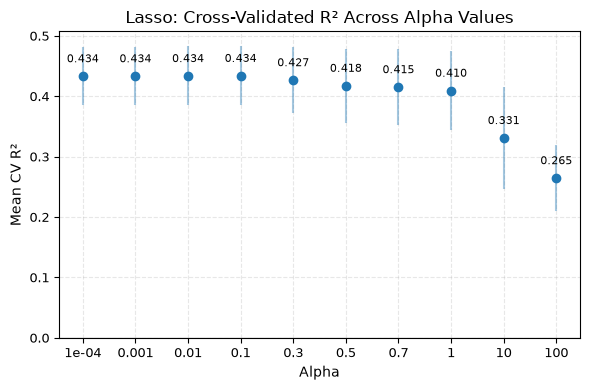

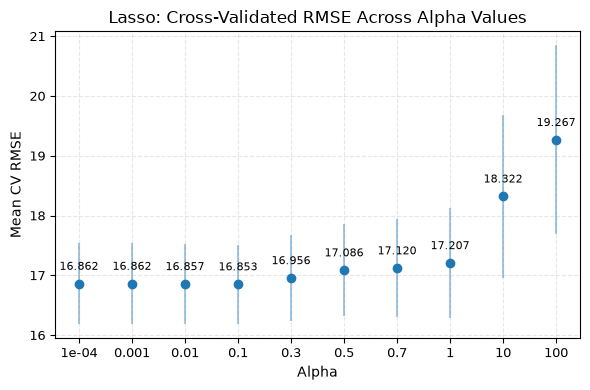

,Standardisation,cv_R2 mean,cv_R2 std,cv_RMSE mean,cv_RMSE std
M2 Lasso,None,0.418,0.158,16.683,1.219


In [8]:
# Hyperparameter tuning using 5-fold cross-validation
alphas = [0.0001, 0.001, 0.01, 0.1, 0.3, 0.5, 0.7, 1, 10, 100]

rsq_mean, rsq_std, rmse_mean, rmse_std = evaluate_alpha_values(Lasso, None, alphas, X, y)

plot_alpha_results(alphas, rsq_mean, rsq_std, "R-squared", "Lasso")
plot_alpha_results(alphas, rmse_mean, rmse_std, "RMSE", "Lasso")


# Evaluation of the chosen model using 10-fold cross-validation
alpha_index = 3
M2 = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("model", Lasso(alpha=alphas[alpha_index])),
    ]
)

evaluate_chosen_model("M2 Lasso", "None", M2)

### Model 3: Ridge Regression

Linear model with L2 regularisation to reduce coefficient magnitude and instability.

- No feature standardisation
- Ridge regression

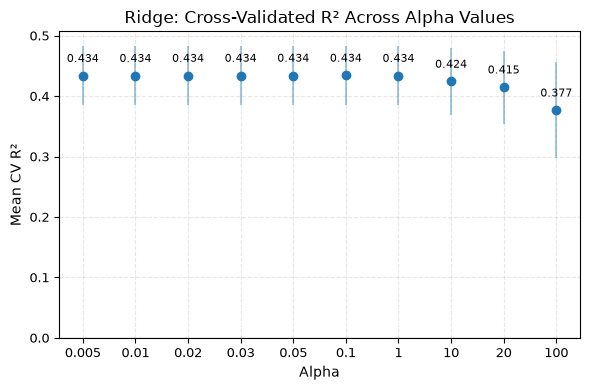

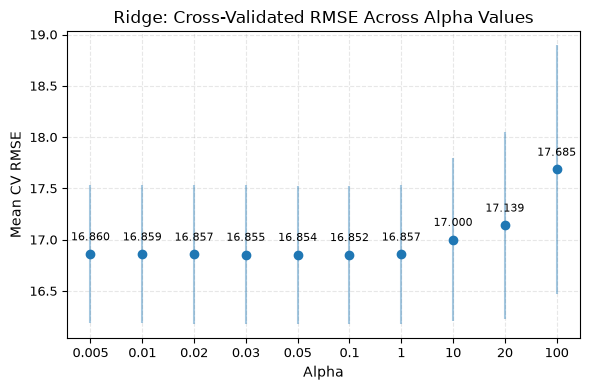

,Standardisation,cv_R2 mean,cv_R2 std,cv_RMSE mean,cv_RMSE std
M3 Ridge,None,0.418,0.156,16.693,1.162


In [9]:
# Hyperparameter tuning using 5-fold cross-validation
alphas = [0.005, 0.01, 0.02, 0.03, 0.05, 0.1, 1, 10, 20, 100]

rsq_mean, rsq_std, rmse_mean, rmse_std = evaluate_alpha_values(Ridge, None, alphas, X, y)

plot_alpha_results(alphas, rsq_mean, rsq_std, "R-squared", "Ridge")
plot_alpha_results(alphas, rmse_mean, rmse_std, "RMSE", "Ridge")

# Evaluation of the chosen model using 10-fold cross-validation
alpha_index = 5
M3 = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("model", Ridge(alpha=alphas[alpha_index])),
    ]
)

evaluate_chosen_model("M3 Ridge", "None", M3)

### Model 4: Linear Regression with Standardisation

Linear regression applied to standardised predictors for comparison with the unscaled model.

- Standard scaling
- Linear regression

In [10]:
# Evaluation of the chosen model using 10-fold cross-validation
model = LinearRegression()
M4 = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model),
    ]
)

evaluate_chosen_model("M4 LinearRegression", "Standardised", M4)

,Standardisation,cv_R2 mean,cv_R2 std,cv_RMSE mean,cv_RMSE std
M4 LinearRegression,Standardised,0.416,0.153,16.728,1.095


### Model 5: Lasso Regression with Standardisation

Lasso applied to standardised predictors so regularisation acts more consistently across features.

- Standard scaling
- Lasso regression

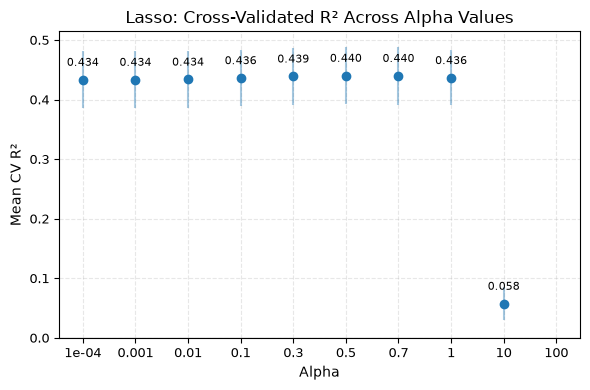

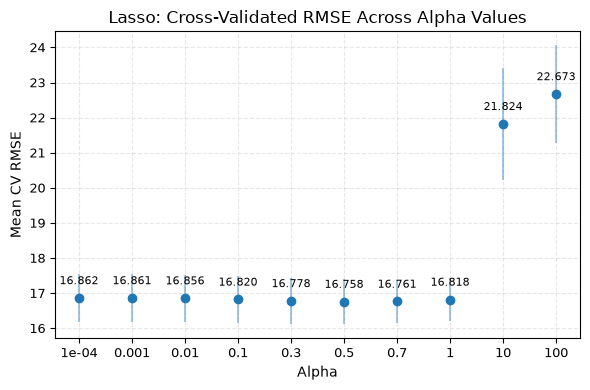

,Standardisation,cv_R2 mean,cv_R2 std,cv_RMSE mean,cv_RMSE std
M5 Lasso,Standardised,0.423,0.144,16.657,1.066


In [11]:
# Hyperparameter tuning using 5-fold cross-validation
alphas = [0.0001, 0.001, 0.01, 0.1, 0.3, 0.5, 0.7, 1, 10, 100]

rsq_mean, rsq_std, rmse_mean, rmse_std = evaluate_alpha_values(Lasso, StandardScaler, alphas, X, y)

plot_alpha_results(alphas, rsq_mean, rsq_std, "R-squared", "Lasso")
plot_alpha_results(alphas, rmse_mean, rmse_std, "RMSE", "Lasso")


# Evaluation of the chosen model using 10-fold cross-validation
alpha_index = 5
model = Lasso(alpha=alphas[alpha_index])
M5 = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model),
    ]
)

evaluate_chosen_model("M5 Lasso", "Standardised", M5)

### Model 6: Ridge Regression with Standardisation

Ridge applied to standardised predictors so regularisation acts more consistently across features.

- Standard scaling
- Ridge regression

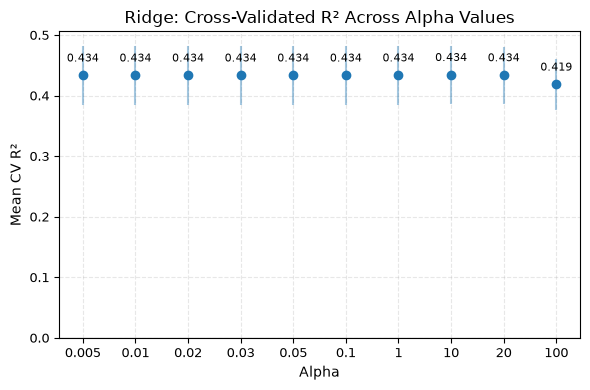

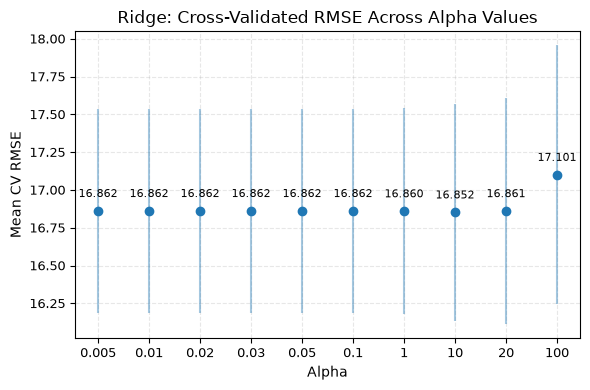

,Standardisation,cv_R2 mean,cv_R2 std,cv_RMSE mean,cv_RMSE std
M6 Ridge,Standardised,0.418,0.149,16.717,1.102


In [12]:
# Hyperparameter tuning using 5-fold cross-validation
alphas = [0.005, 0.01, 0.02, 0.03, 0.05, 0.1, 1, 10, 20, 100]

rsq_mean, rsq_std, rmse_mean, rmse_std = evaluate_alpha_values(Ridge, StandardScaler, alphas, X, y)

plot_alpha_results(alphas, rsq_mean, rsq_std, "R-squared", "Ridge")
plot_alpha_results(alphas, rmse_mean, rmse_std, "RMSE", "Ridge")


# Evaluation of the chosen model using 10-fold cross-validation
alpha_index = 7
model = Ridge(alpha=alphas[alpha_index])
M6 = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model),
    ]
)

evaluate_chosen_model("M6 Ridge", "Standardised", M6)

### Model 7: Decision Tree Regression

Non-linear model that captures feature interactions and threshold effects.

- No feature standardisation
- Decision tree regressor

In [13]:
# Hyperparameter tuning using 5-fold cross-validation
dt = DecisionTreeRegressor(random_state=27)
dt_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", dt)])
params_dt = {
    "model__max_depth": [2, 3, 4, 5],
    "model__min_samples_leaf": [0.5, 0.10, 0.12, 0.14, 0.16, 0.18],
}
grid_dt = GridSearchCV(
    estimator=dt_pipeline, param_grid=params_dt, cv=tuning_cv, n_jobs=-1, verbose=2
)
grid_dt.fit(X, y)

show(grid_dt.best_estimator_, "Best Model from GridSearchCV")
show(grid_dt.best_params_, "Params of Best Model from GridSearchCV")


# Evaluation of the chosen model using 10-fold cross-validation
M7 = grid_dt.best_estimator_

evaluate_chosen_model("M7 RegressionTree", "Not required", M7)

Fitting 5 folds for each of 24 candidates, totalling 120 fits

>> Best Model from GridSearchCV
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 DecisionTreeRegressor(max_depth=4, min_samples_leaf=0.12,
                                       random_state=27))])

>> Params of Best Model from GridSearchCV
{'model__max_depth': 4, 'model__min_samples_leaf': 0.12}


,Standardisation,cv_R2 mean,cv_R2 std,cv_RMSE mean,cv_RMSE std
M7 RegressionTree,Not required,0.356,0.177,17.627,1.944


### Model 8: Random Forest Regression

Ensemble of decision trees that captures non-linear relationships while reducing the instability of a single tree.

- No feature standardisation
- Random forest regressor

In [14]:
# Hyperparameter tuning using 5-fold cross-validation
rf = RandomForestRegressor(random_state=27)
rf_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", rf)])
params_rf = {
    "model__n_estimators": [100, 350, 500],
    "model__max_features": ["log2", "sqrt", None],
    "model__min_samples_leaf": [1, 2, 5, 10, 20],
}
grid_rf = GridSearchCV(
    estimator=rf_pipeline, param_grid=params_rf, cv=tuning_cv, n_jobs=-1, verbose=2
)
grid_rf.fit(X, y)

show(grid_rf.best_estimator_, "Best Model from GridSearchCV")
show(grid_rf.best_params_, "Params of Best Model from GridSearchCV")


# Evaluation of the chosen model using 10-fold cross-validation
M8 = grid_rf.best_estimator_

evaluate_chosen_model("M8 RandomForest", "Not required", M8)

Fitting 5 folds for each of 45 candidates, totalling 225 fits

>> Best Model from GridSearchCV
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 RandomForestRegressor(max_features='log2', n_estimators=500,
                                       random_state=27))])

>> Params of Best Model from GridSearchCV
{'model__max_features': 'log2', 'model__min_samples_leaf': 1, 'model__n_estimators': 500}


,Standardisation,cv_R2 mean,cv_R2 std,cv_RMSE mean,cv_RMSE std
M8 RandomForest,Not required,0.527,0.117,15.133,1.62


### Model 9: Stochastic Gradient Boosting Regression

Sequential tree ensemble that iteratively improves predictions by correcting previous errors.

- No feature standardisation
- Gradient boosting regressor

In [15]:
# Hyperparameter tuning using 5-fold cross-validation
sgbr = GradientBoostingRegressor(random_state=27)
sgbr_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", sgbr)])
params_sgbr = {
    "model__n_estimators": [100, 300, 500],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [1, 2, 3],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__subsample": [0.7, 0.9, 1.0],
}
grid_sgbr = GridSearchCV(
    estimator=sgbr_pipeline, param_grid=params_sgbr, cv=tuning_cv, n_jobs=-1, verbose=2
)
grid_sgbr.fit(X, y)

show(grid_sgbr.best_estimator_, "Best Model from GridSearchCV")
show(grid_sgbr.best_params_, "Params of Best Model from GridSearchCV")


# Evaluation of the chosen model using 10-fold cross-validation
M9 = grid_sgbr.best_estimator_

evaluate_chosen_model("M9 Stochastic Gradient Boosting Regressor", "Not required", M9)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits

>> Best Model from GridSearchCV
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=300,
                                           random_state=27, subsample=0.7))])

>> Params of Best Model from GridSearchCV
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__n_estimators': 300, 'model__subsample': 0.7}


,Standardisation,cv_R2 mean,cv_R2 std,cv_RMSE mean,cv_RMSE std
M9 Stochastic Gradient Boosting Regressor,Not required,0.503,0.141,15.421,1.496


### Model 10: Neural Network Regression (MLP)

Flexible non-linear model capable of learning complex relationships between predictors.

- Standard scaling of predictors
- Standard scaling of the target during fitting
- Multilayer perceptron regressor

In [16]:
# Hyperparameter tuning using 5-fold cross-validation
mlp = MLPRegressor(random_state=27, max_iter=2000)

mlp_pipeline = Pipeline(
    [("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("mlp", mlp)]
)

mlp_model = TransformedTargetRegressor(regressor=mlp_pipeline, transformer=StandardScaler())

params_mlp = {
    "regressor__mlp__hidden_layer_sizes": [(10,), (20,), (10, 10), (20, 10)],
    "regressor__mlp__activation": ["relu", "tanh"],
    "regressor__mlp__solver": ["adam", "lbfgs"],
    "regressor__mlp__alpha": [0.001, 0.01, 0.1, 1],
}

grid_mlp = GridSearchCV(
    estimator=mlp_model, param_grid=params_mlp, cv=tuning_cv, n_jobs=-1, verbose=2
)

grid_mlp.fit(X, y)

show(grid_mlp.best_estimator_, "Best MLP from GridSearchCV")
show(grid_mlp.best_params_, "Params of Best MLP from GridSearchCV")

# Evaluation of the chosen model using 10-fold cross-validation
M10 = grid_mlp.best_estimator_

evaluate_chosen_model("M10 Neural Network Regressor (MLP)", "Standardised", M10)

Fitting 5 folds for each of 64 candidates, totalling 320 fits

>> Best MLP from GridSearchCV
TransformedTargetRegressor(regressor=Pipeline(steps=[('imputer',
                                                      SimpleImputer(strategy='median')),
                                                     ('scaler',
                                                      StandardScaler()),
                                                     ('mlp',
                                                      MLPRegressor(activation='tanh',
                                                                   alpha=1,
                                                                   hidden_layer_sizes=(20,),
                                                                   max_iter=2000,
                                                                   random_state=27))]),
                           transformer=StandardScaler())

>> Params of Best MLP from GridSearchCV
{'regressor__mlp__activation': '

,Standardisation,cv_R2 mean,cv_R2 std,cv_RMSE mean,cv_RMSE std
M10 Neural Network Regressor (MLP),Standardised,0.448,0.147,16.274,1.523


## Model Comparison

M8 Random Forest has the highest mean CV R² (0.527) among the models compared, followed by M9 Gradient Boosting (0.503). Among the linear models, M5 scaled Lasso has the highest mean CV R² (0.423).

The chart shows mean 10-fold CV R² with error bars representing one standard deviation across folds, rather than confidence intervals. The table also reports mean fold RMSE. These comparisons are exploratory because hyperparameter tuning and evaluation use the same dataset, so performance estimates may be optimistic.

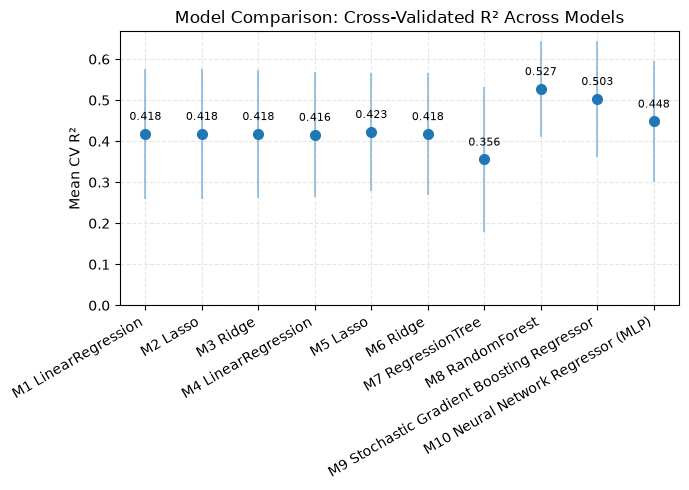

,Standardisation,cv_R2 mean,cv_R2 std,cv_RMSE mean,cv_RMSE std
M1 LinearRegression,None,0.418,0.158,16.681,1.202
M2 Lasso,None,0.418,0.158,16.683,1.219
M3 Ridge,None,0.418,0.156,16.693,1.162
M4 LinearRegression,Standardised,0.416,0.153,16.728,1.095
M5 Lasso,Standardised,0.423,0.144,16.657,1.066
M6 Ridge,Standardised,0.418,0.149,16.717,1.102
M7 RegressionTree,Not required,0.356,0.177,17.627,1.944
M8 RandomForest,Not required,0.527,0.117,15.133,1.620
M9 Stochastic Gradient Boosting Regressor,Not required,0.503,0.141,15.421,1.496
M10 Neural Network Regressor (MLP),Standardised,0.448,0.147,16.274,1.523


In [17]:
plt.close()
fig, ax = plt.subplots(figsize=(7, 5))
error_bars = ax.errorbar(
    models_df.index,
    models_df["cv_R2 mean"],
    yerr=models_df["cv_R2 std"],
    fmt="o",
    color="tab:blue",
    capsize=0,
    markersize=7,
)
for bar_collection in error_bars.lines[2]:
    bar_collection.set_alpha(0.4)

for i, (_, row) in enumerate(models_df.iterrows()):
    ax.annotate(
        f"{row['cv_R2 mean']:.3f}",
        (i, row["cv_R2 mean"]),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        va="bottom",
        fontsize=8,
    )

ax.tick_params(axis="x", labelrotation=30)
plt.setp(ax.get_xticklabels(), ha="right")
ax.set_ylabel("Mean CV R²")
ax.set_title("Model Comparison: Cross-Validated R² Across Models")
ax.grid(True, linestyle="--", alpha=0.3)
ax.set_ylim(bottom=0)
fig.tight_layout()
plt.show()

display(models_df.round(3))

### Training and Cross-Validation Performance of Selected Models

M8 Random Forest and M5 scaled Lasso represent the leading non-linear and linear candidates by mean CV R². Comparing training and cross-validation metrics provides an indication of the extent of overfitting.

In [18]:
def training_cv_comparison(model_label, model, X, y):
    """Fit a model and compare training metrics with its recorded CV means."""
    if not models_df.index.is_unique:
        raise ValueError("Expected one CV result per model label.")

    model.fit(X, y)
    training_predictions = model.predict(X)
    cv_results = models_df.loc[model_label]

    return pd.DataFrame(
        {
            "Training R²": [r2_score(y, training_predictions)],
            "CV R²": [cv_results["cv_R2 mean"]],
            "Training RMSE": [np.sqrt(mean_squared_error(y, training_predictions))],
            "CV RMSE": [cv_results["cv_RMSE mean"]],
        },
        index=pd.Index([model_label], name="Model"),
    )


performance_comparison = pd.concat(
    [
        training_cv_comparison("M8 RandomForest", M8, X, y),
        training_cv_comparison("M5 Lasso", M5, X, y),
    ]
)
display(performance_comparison.round(3))

,Training R²,CV R²,Training RMSE,CV RMSE
Model,,,,
M8 RandomForest,0.938,0.527,5.629,15.133
M5 Lasso,0.488,0.423,16.197,16.657


M8's training R² (**0.938**) is substantially higher than its mean CV R² (**0.527**), indicating overfitting. M5 has a smaller gap (**0.488** versus **0.423**).

A subsequent, more focused hyperparameter search did not materially improve cross-validated performance or reduce overfitting, so the original tuned Random Forest was retained.

## Models Selected for Interpretation

M8 Random Forest is used for SHAP interpretation, with M5 scaled Lasso providing a complementary linear interpretation.

In [19]:
rf_model = M8  # Selected non-linear model
lasso_model = M5  # Complementary linear model

## SHAP Analysis: Model 8 Random Forest

SHAP (SHapley Additive exPlanations) values explain how individual features influence a model’s predictions by attributing the difference between a prediction and its baseline output to those features. Aggregated SHAP values can also be used to assess feature importance within the fitted model. Positive contributions increase the prediction relative to the baseline, while negative contributions decrease it. Contributions are expressed in strength-index points.

TreeExplainer is applied to the fitted Random Forest using feature values processed by the model’s fitted median imputer. The target is expressed as a relative strength index, with 100 representing the mean observed flexural strength in the modelling dataset. In the SHAP explanations, `E[f(X)]` represents the fitted model’s expected output and therefore does not necessarily equal 100. The resulting SHAP values describe the behaviour of the fitted model on the available data, but do not establish causal relationships or independently validate the identified patterns.

In [20]:
# Apply the fitted imputer before calculating SHAP values.
X_shap = pd.DataFrame(
    rf_model.named_steps["imputer"].transform(X),
    columns=rf_model.named_steps["imputer"].get_feature_names_out(),
    index=X.index,
)
explainer = shap.TreeExplainer(rf_model.named_steps["model"])
shap_values = explainer.shap_values(X_shap)

base_value = np.asarray(explainer.expected_value).item()

### Global Feature Importance

Mean absolute SHAP values rank features by the average magnitude of their contributions across the modelling dataset. This ranking describes the fitted model and does not by itself establish causality or independent feature effects.

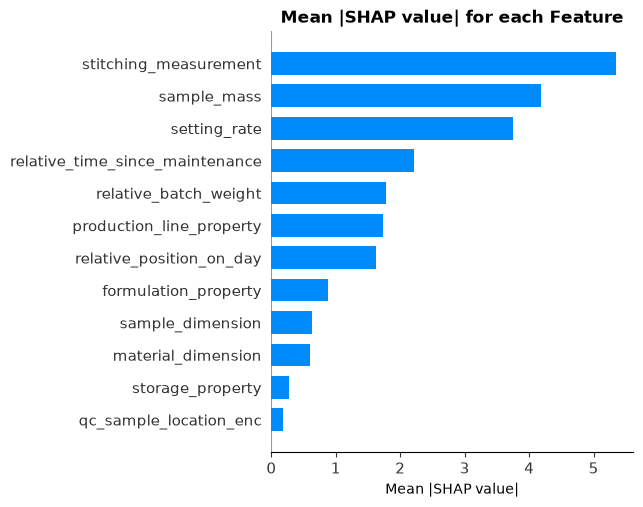

In [21]:
plt.close()
shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False, plot_size=(7, 5))
plt.title("Mean |SHAP value| for each Feature", fontsize=12, fontweight="bold")
plt.xlabel("Mean |SHAP value|", fontsize=10)
plt.yticks(fontsize=11)
plt.show()

# Global importance ranking for the dependence plots.
feature_importance_df = pd.DataFrame(
    {"Feature": X_shap.columns, "Mean_Abs_SHAP": np.abs(shap_values).mean(axis=0)}
).sort_values("Mean_Abs_SHAP", ascending=False)

**Interpretation:** `stitching_measurement`, `sample_mass`, and `setting_rate` have the largest mean absolute SHAP values. They contribute most strongly, on average, to the model’s predictions. Correlated features may share predictive information, so the ranking should not be treated as a measure of each feature’s unique contribution.

### SHAP Contribution Distributions

The beeswarm plot shows the distribution of SHAP contributions for each feature across observations. Colour indicates relatively high (red) or low (blue) feature values, while horizontal position shows the direction and magnitude of each contribution relative to the explainer’s baseline.

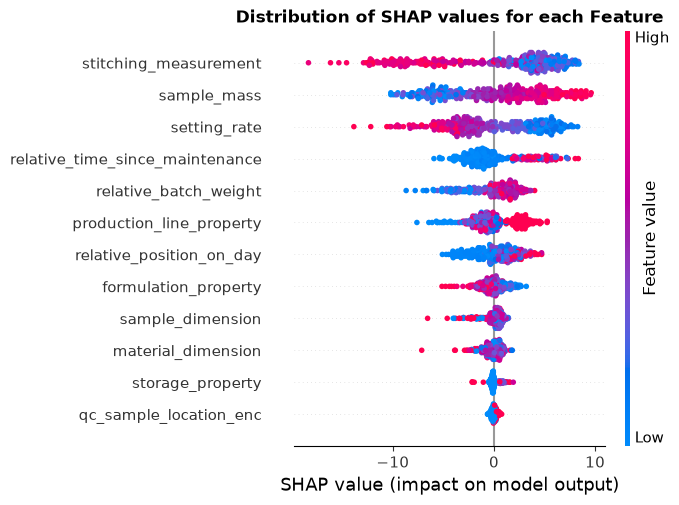

In [22]:
plt.close()
shap.summary_plot(shap_values, X_shap, show=False, plot_size=(7.5, 5))
plt.title("Distribution of SHAP values for each Feature", fontsize=12, fontweight="bold")
plt.yticks(fontsize=11)
colorbar_ax = plt.gcf().axes[-1]
low_label, high_label = colorbar_ax.get_yticklabels()
low_label.set_verticalalignment("bottom")
high_label.set_verticalalignment("top")
colorbar_ax.yaxis.labelpad = -20
plt.show()

**Interpretation:** Higher `sample_mass` values generally accompany positive SHAP contributions, while higher `stitching_measurement` and `setting_rate` values generally accompany negative contributions. Contributions vary across observations; these patterns describe associations learned by M8 rather than the effect of changing a feature in practice.

### Dependence Plots for the Leading Features

The four features with the largest mean absolute SHAP values are plotted against their SHAP contributions. Colour indicates another feature selected automatically by SHAP, helping reveal potential interactions or shared structure. These patterns do not establish causal relationships.

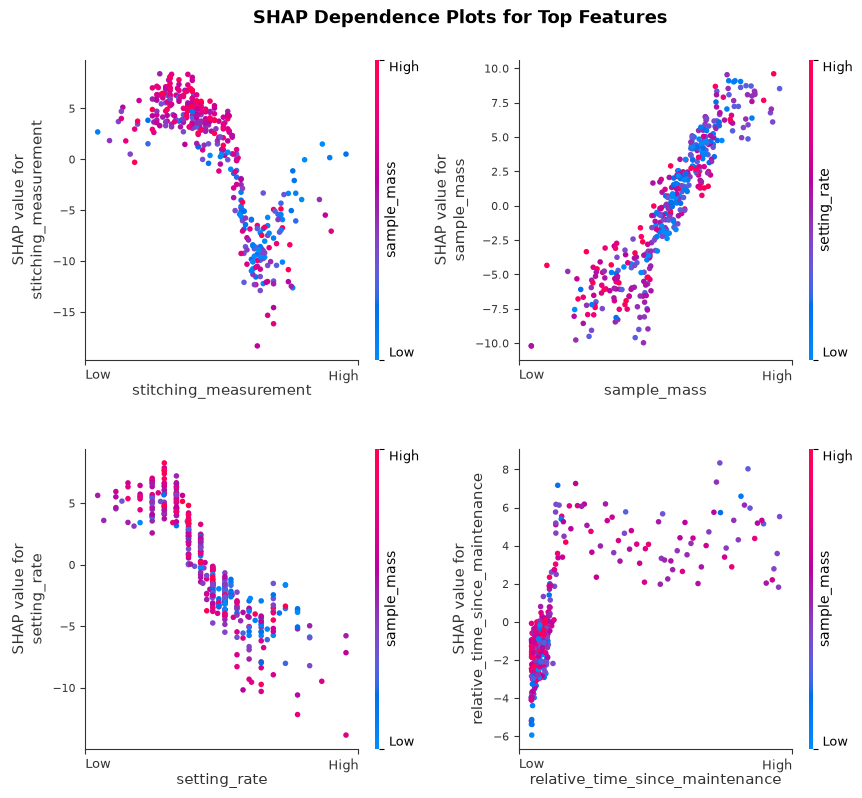

In [23]:
# Four leading features by mean absolute SHAP contribution.
top_features = feature_importance_df.iloc[:4]["Feature"].tolist()

plt.close()
fig, axes = plt.subplots(2, 2, figsize=(10, 8.5), gridspec_kw={"wspace": 0.27, "hspace": 0.3})

for ax, feature in zip(axes.flat, top_features):
    existing_axes = set(fig.axes)
    shap.dependence_plot(feature, shap_values, X_shap, show=False, ax=ax)
    ax.xaxis.label.set_fontsize(11)
    ax.yaxis.label.set_fontsize(11)
    ax.tick_params(axis="x", labelsize=9)
    ax.tick_params(axis="y", labelsize=8)
    ax.set_xticks(ax.get_xlim(), labels=["Low", "High"])
    ax.set_xticks([], minor=True)
    ax.tick_params(axis="x", labelrotation=0)
    low_label, high_label = ax.get_xticklabels()
    low_label.set_horizontalalignment("left")
    high_label.set_horizontalalignment("right")
    ax.xaxis.labelpad = 0
    ax.xaxis.get_offset_text().set_visible(False)

    for colorbar_ax in set(fig.axes) - existing_axes:
        colorbar_ax.set_yticks(colorbar_ax.get_ylim(), labels=["Low", "High"])
        colorbar_ax.set_yticks([], minor=True)
        colorbar_ax.yaxis.label.set_fontsize(10)
        colorbar_ax.tick_params(axis="y", labelsize=9)
        low_label, high_label = colorbar_ax.get_yticklabels()
        low_label.set_verticalalignment("bottom")
        high_label.set_verticalalignment("top")
        colorbar_ax.yaxis.labelpad = -25
        colorbar_ax.yaxis.get_offset_text().set_visible(False)

plt.suptitle("SHAP Dependence Plots for Top Features", fontsize=13, fontweight="bold")
fig.subplots_adjust(top=0.92)
plt.show()

**Interpretation:** The plots reveal non-linear patterns, particularly for `stitching_measurement` and `relative_time_since_maintenance`. SHAP contributions generally increase with `sample_mass` and decrease with `setting_rate`. Variation in contributions at similar feature values may indicate interactions with other features.

### Individual Prediction Explanations

Waterfall plots decompose the highest, lowest, and nearest-to-median fitted predictions into the baseline prediction and individual feature contributions. These selected training observations illustrate contrasting model behaviour and are not intended to assess predictive accuracy. Raw feature values and measured targets are omitted for confidentiality.

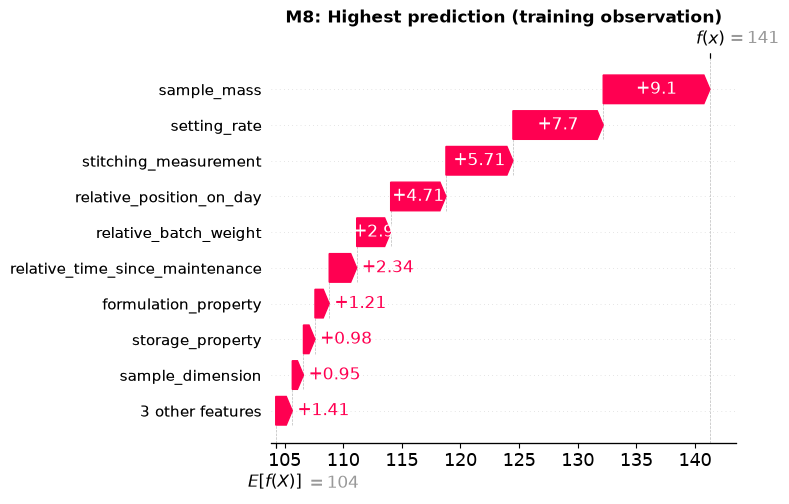

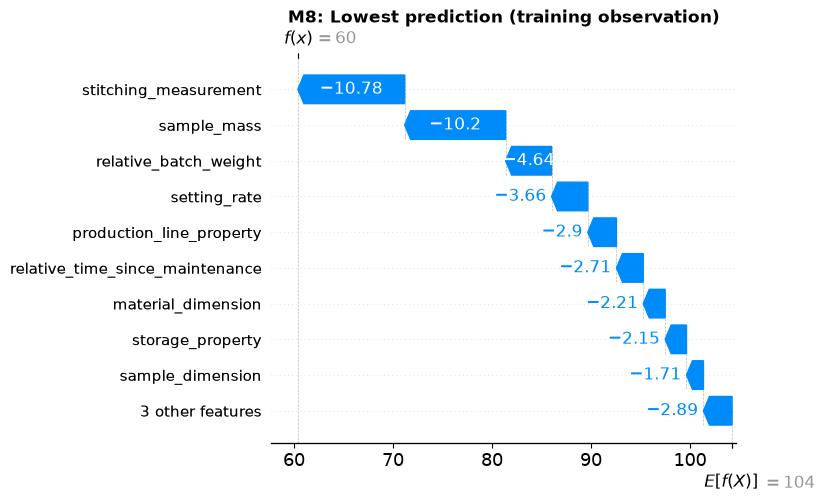

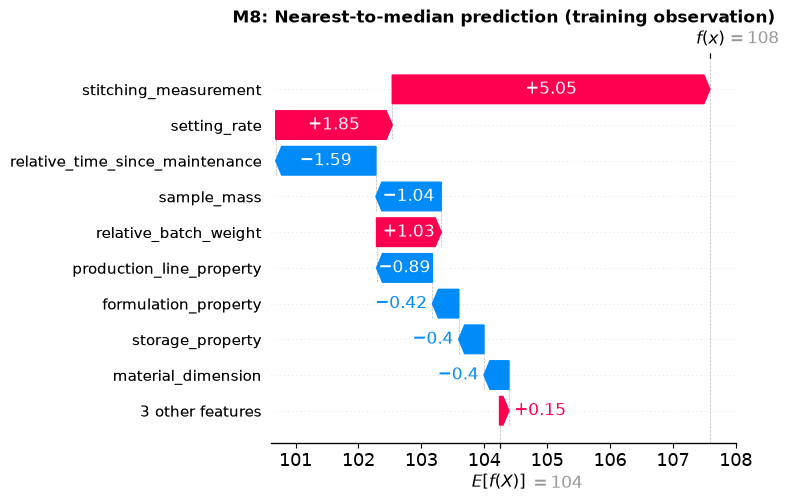

In [24]:
# Select contrasting examples based on fitted predictions.
training_predictions = rf_model.predict(X)
sample_high = np.argmax(training_predictions)
sample_low = np.argmin(training_predictions)
sample_median = np.argsort(np.abs(training_predictions - np.median(training_predictions)))[0]

samples_to_explain = [sample_high, sample_low, sample_median]
sample_labels = ["Highest prediction", "Lowest prediction", "Nearest-to-median prediction"]

for sample_idx, label in zip(samples_to_explain, sample_labels):
    # Display feature contributions without raw input values.
    explanation = shap.Explanation(
        values=shap_values[sample_idx],
        base_values=base_value,
        feature_names=X_shap.columns.tolist(),
    )

    plt.close()
    shap.waterfall_plot(explanation, show=False)
    plt.gcf().set_size_inches(6, 5)
    plt.title(f"M8: {label} (training observation)", fontweight="bold", fontsize=12)
    ax, baseline_ax, prediction_ax = plt.gcf().axes
    ax.tick_params(axis="y", labelsize=11)
    baseline_ax.set_xticklabels(["\n$E[f(X)]$", f"\n$ = {base_value:.0f}$"])
    prediction_ax.set_xticklabels(["$f(x)$", f"$ = {base_value + explanation.values.sum():.0f}$"])
    plt.show()

**Interpretation:** Each waterfall shows how positive and negative feature contributions combine with the baseline to produce a fitted prediction. The three examples illustrate contrasting model behaviour; because they are selected training observations, they do not provide evidence of generalisation to unseen data.

### Limits of Model Interpretation

The Random Forest's training R² is **0.938**, compared with a mean CV R² of **0.527** and a fold standard deviation of **0.117**. This gap indicates substantial overfitting and limits confidence that the fitted relationships will generalise to unseen data.

SHAP explains the fitted model rather than validating it. Lasso coefficients provide a complementary linear view, but agreement between models trained on the same data is not independent confirmation.

## Coefficient Analysis: Model 5 Lasso

M5 uses standardised predictors, allowing coefficient magnitudes to be compared across features measured on different scales. For continuous predictors, each coefficient represents the change in predicted strength index associated with a one-standard-deviation increase in that feature, holding the other predictors fixed.

Coefficient signs indicate the direction of the fitted association. Regularisation can shrink coefficients towards zero, and correlation between predictors can redistribute coefficient magnitude between related features. A small or zero coefficient therefore does not demonstrate that a feature is irrelevant. For the binary location feature, `qc_sample_location_enc`, a one-standard-deviation increase does not correspond directly to switching from 0 to 1.

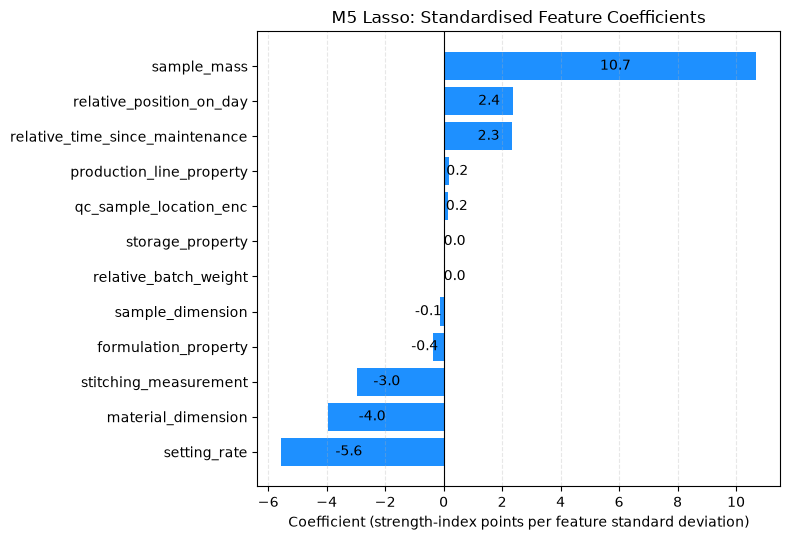

In [25]:
# Full-data fit for coefficient interpretation.
lasso_model.fit(X, y)

# Coefficients correspond to predictors after standardisation.
coefficients = lasso_model.named_steps["model"].coef_

coefficients_df = pd.DataFrame(
    {
        "Feature": lasso_model.named_steps["imputer"].get_feature_names_out(),
        "Coefficient": coefficients,
        "Abs_Coefficient": np.abs(coefficients),
    }
).sort_values("Abs_Coefficient", ascending=False)

plot_df = coefficients_df.sort_values("Coefficient")

plt.close()
fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.barh(plot_df["Feature"], plot_df["Coefficient"], color="dodgerblue")
ax.axvline(0, color="k", lw=0.8)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width / 2,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}",
        va="center",
        ha="left" if width >= 0 else "right",
        fontsize=10,
    )
ax.set_xlabel("Coefficient (strength-index points per feature standard deviation)")
ax.set_title("M5 Lasso: Standardised Feature Coefficients")
ax.grid(axis="x", linestyle="--", alpha=0.3)

fig.tight_layout()
plt.show()

**Interpretation:** `sample_mass` has the largest positive coefficient; `setting_rate` and `material_dimension` have the largest negative coefficients. `stitching_measurement` also has a negative coefficient, while `relative_position_on_day` and `relative_time_since_maintenance` have smaller positive coefficients. The coefficients for `relative_batch_weight` and `storage_property` round to zero at the displayed precision.

## Conclusions and Limitations

Random Forest achieves the highest mean CV R² among the models tested at 0.527 ± 0.117, compared with 0.423 ± 0.144 for M5 Lasso, where ± denotes the standard deviation across the 10 CV folds. Mean fold RMSE is 15.133 for Random Forest and 16.657 for Lasso, in strength-index points. These values describe variation across folds rather than confidence intervals.

SHAP and Lasso coefficients highlight complementary aspects of the fitted relationships:

| Rank | Random Forest: mean \|SHAP\| | Lasso: \|coefficient\| |
| ---- | ----------------------------- | ---------------------- |
| 1 | `stitching_measurement` (−) | `sample_mass` (+) |
| 2 | `sample_mass` (+) | `setting_rate` (−) |
| 3 | `setting_rate` (−) | `material_dimension` (−) |

(+) and (−) indicate the direction of the variable’s contribution to the prediction.

The beeswarm plot shows generally positive contributions for higher `sample_mass` and negative contributions for higher `stitching_measurement` and `setting_rate`. Differences between the SHAP and Lasso rankings may reflect non-linearity, regularisation, correlated predictors, or interactions; examining feature correlations or grouped SHAP effects could help distinguish these explanations.

The findings have three main limitations that could be addressed in future work:

- **Overfitting:** The Random Forest performs substantially better on the fitted data than under cross-validation. Further work could investigate stronger regularisation, additional data, or simpler models.
- **Selection bias:** Hyperparameter tuning and model comparison use the same dataset, so performance estimates may be optimistic. Nested cross-validation or a separate held-out test set would provide a stronger evaluation.
- **Temporal generalisation:** Shuffled CV does not directly test later production runs or changing process conditions. A time-based validation split would better assess performance on future production data.

Overall, Random Forest provides the strongest cross-validated predictive performance, while SHAP and Lasso provide complementary views of the factors associated with strength variation. The most important next steps are validation on future production data and targeted production trials to test whether the identified relationships can support improvements in product strength.